# Exercise 6 - DSAC

## Import packages

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import torch

from skimage.draw import line, line_aa, set_color, circle_perimeter_aa

# 讓新版 skimage 也有 circle 可以用
try:
    from skimage.draw import circle
except ImportError:
    from skimage.draw import disk as _disk
    def circle(r, c, radius):
        rr, cc = _disk((r, c), radius)
        return rr, cc

from skimage.util import random_noise

from vll.utils.train_dsac import default_params, train_line_dsac, train_circle_dsac
from vll.visualize.dsac import visualize_circle_dsac

from vll.data.circle_dataset import ICircleDataset
from vll.utils.circle_loss import ICircleLoss
from vll.utils.circle_dsac import ICircleDSAC

## Task 1
(2 points)

Run the line fitting example (~100 iterations). Plot the training losses.

In [2]:
def running_mean(X, Y, window):
    '''
    Compute the running mean (similar to exercise 1), already implemented

    X -- values for X (for cropping)
    Y -- values for Y (for filtering)
    window -- window size for mean filter
    '''
    offset = window // 2
    x = X[offset:-offset]
    y = np.convolve(Y, np.repeat(1.0, window) / window, mode='valid')
    return x, y


def plot_loss(log_file_path):
    iters = []
    dsac_top_losses = []
    direct_losses = []

    with open(log_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # split by ANY whitespace（比 csv.reader 健壯）
            parts = line.split()

            # 檢查格式是否符合
            if len(parts) < 4:
                continue  # 或 print("Skipping line:", line)

            it = int(parts[0])
            dsac_top = float(parts[2])
            direct = float(parts[3])

            iters.append(it)
            dsac_top_losses.append(dsac_top)
            direct_losses.append(direct)

    iters = np.array(iters)
    dsac_top_losses = np.array(dsac_top_losses)
    direct_losses = np.array(direct_losses)

    # 平滑
    window = 9  # 一定要用「奇數」
    xm, dsac_sm = running_mean(iters, dsac_top_losses, window)
    xm2, direct_sm = running_mean(iters, direct_losses, window)

    plt.plot(xm, dsac_sm, label="DSAC Top Loss")
    plt.plot(xm2, direct_sm, label="Direct Loss")

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    
    
    

Iteration:      0, DSAC Expected Loss: 63.55, DSAC Top Loss: 61.00, Direct Loss: 77.43, Time: 2.08s


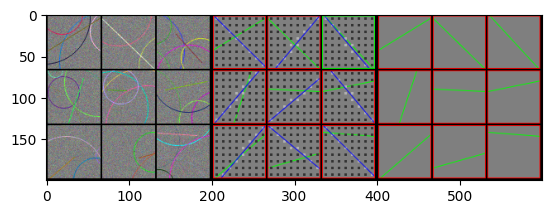

Storing snapshot. Validation loss: 59.85
Iteration:      1, DSAC Expected Loss: 65.17, DSAC Top Loss: 65.31, Direct Loss: 81.39, Time: 1.93s
Iteration:      2, DSAC Expected Loss: 59.93, DSAC Top Loss: 65.78, Direct Loss: 83.15, Time: 1.86s
Iteration:      3, DSAC Expected Loss: 59.42, DSAC Top Loss: 56.80, Direct Loss: 69.46, Time: 1.90s
Iteration:      4, DSAC Expected Loss: 58.24, DSAC Top Loss: 61.72, Direct Loss: 63.33, Time: 1.87s
Iteration:      5, DSAC Expected Loss: 64.50, DSAC Top Loss: 64.88, Direct Loss: 72.74, Time: 1.90s
Iteration:      6, DSAC Expected Loss: 59.99, DSAC Top Loss: 57.86, Direct Loss: 78.64, Time: 1.89s
Iteration:      7, DSAC Expected Loss: 63.67, DSAC Top Loss: 62.72, Direct Loss: 72.52, Time: 1.86s
Iteration:      8, DSAC Expected Loss: 60.27, DSAC Top Loss: 55.58, Direct Loss: 71.86, Time: 1.88s
Iteration:      9, DSAC Expected Loss: 58.05, DSAC Top Loss: 56.21, Direct Loss: 68.11, Time: 1.83s
Iteration:     10, DSAC Expected Loss: 62.00, DSAC Top Loss

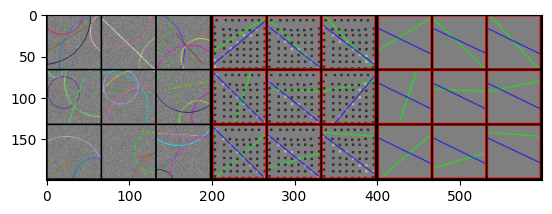

Storing snapshot. Validation loss: 51.37
Iteration:     11, DSAC Expected Loss: 57.87, DSAC Top Loss: 48.60, Direct Loss: 72.59, Time: 1.91s
Iteration:     12, DSAC Expected Loss: 62.28, DSAC Top Loss: 58.48, Direct Loss: 65.21, Time: 1.84s
Iteration:     13, DSAC Expected Loss: 58.80, DSAC Top Loss: 57.13, Direct Loss: 64.71, Time: 1.90s
Iteration:     14, DSAC Expected Loss: 60.25, DSAC Top Loss: 61.87, Direct Loss: 70.70, Time: 1.95s
Iteration:     15, DSAC Expected Loss: 58.69, DSAC Top Loss: 53.75, Direct Loss: 77.40, Time: 1.88s
Iteration:     16, DSAC Expected Loss: 54.79, DSAC Top Loss: 51.54, Direct Loss: 56.07, Time: 1.91s
Iteration:     17, DSAC Expected Loss: 58.92, DSAC Top Loss: 58.92, Direct Loss: 74.30, Time: 1.89s
Iteration:     18, DSAC Expected Loss: 58.77, DSAC Top Loss: 58.50, Direct Loss: 70.63, Time: 1.84s
Iteration:     19, DSAC Expected Loss: 62.87, DSAC Top Loss: 61.60, Direct Loss: 67.24, Time: 1.89s
Iteration:     20, DSAC Expected Loss: 51.81, DSAC Top Loss

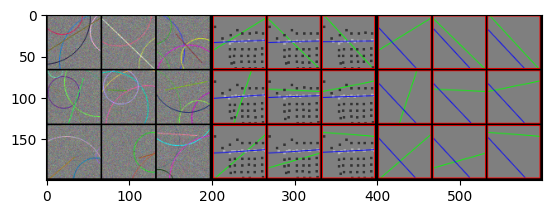

Storing snapshot. Validation loss: 43.39
Iteration:     21, DSAC Expected Loss: 59.89, DSAC Top Loss: 63.36, Direct Loss: 64.54, Time: 1.86s
Iteration:     22, DSAC Expected Loss: 54.60, DSAC Top Loss: 50.54, Direct Loss: 75.86, Time: 1.90s
Iteration:     23, DSAC Expected Loss: 57.22, DSAC Top Loss: 55.59, Direct Loss: 64.38, Time: 1.85s
Iteration:     24, DSAC Expected Loss: 57.05, DSAC Top Loss: 55.64, Direct Loss: 61.70, Time: 1.88s
Iteration:     25, DSAC Expected Loss: 52.79, DSAC Top Loss: 49.77, Direct Loss: 63.55, Time: 1.89s
Iteration:     26, DSAC Expected Loss: 59.45, DSAC Top Loss: 57.41, Direct Loss: 63.85, Time: 1.84s
Iteration:     27, DSAC Expected Loss: 51.91, DSAC Top Loss: 51.00, Direct Loss: 53.80, Time: 1.88s
Iteration:     28, DSAC Expected Loss: 59.77, DSAC Top Loss: 57.47, Direct Loss: 64.42, Time: 1.86s
Iteration:     29, DSAC Expected Loss: 57.57, DSAC Top Loss: 56.63, Direct Loss: 61.70, Time: 1.89s
Iteration:     30, DSAC Expected Loss: 56.99, DSAC Top Loss

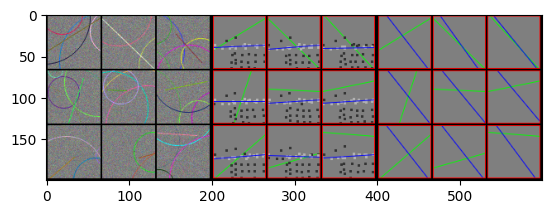

Storing snapshot. Validation loss: 47.64
Iteration:     31, DSAC Expected Loss: 62.50, DSAC Top Loss: 62.07, Direct Loss: 57.22, Time: 1.87s
Iteration:     32, DSAC Expected Loss: 59.80, DSAC Top Loss: 59.63, Direct Loss: 63.67, Time: 1.90s
Iteration:     33, DSAC Expected Loss: 58.75, DSAC Top Loss: 58.82, Direct Loss: 58.90, Time: 1.86s
Iteration:     34, DSAC Expected Loss: 56.24, DSAC Top Loss: 54.29, Direct Loss: 64.04, Time: 1.88s
Iteration:     35, DSAC Expected Loss: 59.93, DSAC Top Loss: 61.66, Direct Loss: 71.46, Time: 1.89s
Iteration:     36, DSAC Expected Loss: 59.51, DSAC Top Loss: 57.82, Direct Loss: 59.70, Time: 1.85s
Iteration:     37, DSAC Expected Loss: 60.89, DSAC Top Loss: 63.17, Direct Loss: 64.24, Time: 1.88s
Iteration:     38, DSAC Expected Loss: 55.87, DSAC Top Loss: 56.42, Direct Loss: 59.60, Time: 1.91s
Iteration:     39, DSAC Expected Loss: 56.63, DSAC Top Loss: 55.75, Direct Loss: 58.47, Time: 1.84s
Iteration:     40, DSAC Expected Loss: 49.73, DSAC Top Loss

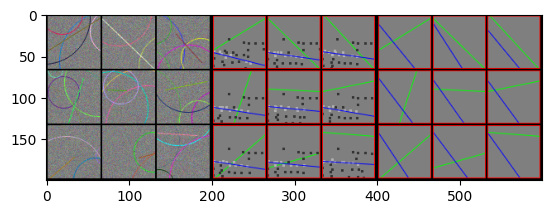

Storing snapshot. Validation loss: 57.77
Iteration:     41, DSAC Expected Loss: 59.39, DSAC Top Loss: 57.20, Direct Loss: 66.65, Time: 1.88s
Iteration:     42, DSAC Expected Loss: 59.02, DSAC Top Loss: 58.37, Direct Loss: 54.47, Time: 1.89s
Iteration:     43, DSAC Expected Loss: 57.00, DSAC Top Loss: 56.73, Direct Loss: 58.14, Time: 1.90s
Iteration:     44, DSAC Expected Loss: 55.44, DSAC Top Loss: 54.60, Direct Loss: 59.28, Time: 1.85s
Iteration:     45, DSAC Expected Loss: 53.33, DSAC Top Loss: 54.76, Direct Loss: 54.74, Time: 1.90s
Iteration:     46, DSAC Expected Loss: 58.30, DSAC Top Loss: 57.93, Direct Loss: 64.98, Time: 1.85s
Iteration:     47, DSAC Expected Loss: 53.64, DSAC Top Loss: 50.76, Direct Loss: 54.72, Time: 1.89s
Iteration:     48, DSAC Expected Loss: 59.30, DSAC Top Loss: 58.94, Direct Loss: 63.80, Time: 1.89s
Iteration:     49, DSAC Expected Loss: 60.00, DSAC Top Loss: 60.98, Direct Loss: 58.05, Time: 1.83s
Iteration:     50, DSAC Expected Loss: 53.99, DSAC Top Loss

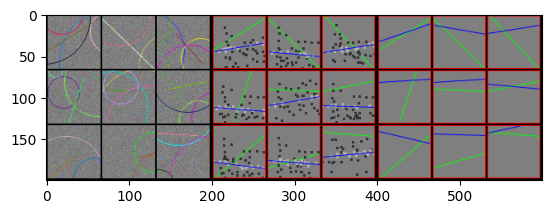

Storing snapshot. Validation loss: 50.27
Iteration:     51, DSAC Expected Loss: 65.39, DSAC Top Loss: 63.93, Direct Loss: 63.88, Time: 1.90s
Iteration:     52, DSAC Expected Loss: 54.96, DSAC Top Loss: 56.54, Direct Loss: 59.36, Time: 1.90s
Iteration:     53, DSAC Expected Loss: 52.81, DSAC Top Loss: 50.31, Direct Loss: 61.41, Time: 1.89s
Iteration:     54, DSAC Expected Loss: 46.19, DSAC Top Loss: 44.79, Direct Loss: 58.01, Time: 1.84s
Iteration:     55, DSAC Expected Loss: 56.94, DSAC Top Loss: 54.65, Direct Loss: 58.99, Time: 1.89s
Iteration:     56, DSAC Expected Loss: 57.64, DSAC Top Loss: 61.68, Direct Loss: 55.08, Time: 1.84s
Iteration:     57, DSAC Expected Loss: 55.99, DSAC Top Loss: 54.70, Direct Loss: 59.83, Time: 1.90s
Iteration:     58, DSAC Expected Loss: 59.55, DSAC Top Loss: 59.10, Direct Loss: 60.42, Time: 1.83s
Iteration:     59, DSAC Expected Loss: 52.40, DSAC Top Loss: 51.46, Direct Loss: 65.01, Time: 1.88s
Iteration:     60, DSAC Expected Loss: 54.74, DSAC Top Loss

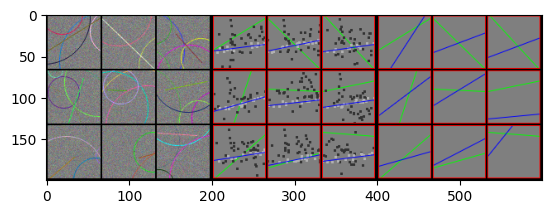

Storing snapshot. Validation loss: 47.05
Iteration:     61, DSAC Expected Loss: 58.85, DSAC Top Loss: 57.70, Direct Loss: 61.09, Time: 1.87s
Iteration:     62, DSAC Expected Loss: 54.72, DSAC Top Loss: 53.74, Direct Loss: 58.89, Time: 1.89s
Iteration:     63, DSAC Expected Loss: 52.83, DSAC Top Loss: 53.31, Direct Loss: 51.87, Time: 1.90s
Iteration:     64, DSAC Expected Loss: 54.71, DSAC Top Loss: 54.93, Direct Loss: 60.88, Time: 1.85s
Iteration:     65, DSAC Expected Loss: 45.75, DSAC Top Loss: 43.38, Direct Loss: 58.07, Time: 1.90s
Iteration:     66, DSAC Expected Loss: 50.43, DSAC Top Loss: 50.33, Direct Loss: 59.05, Time: 1.86s
Iteration:     67, DSAC Expected Loss: 50.09, DSAC Top Loss: 48.38, Direct Loss: 57.14, Time: 1.89s
Iteration:     68, DSAC Expected Loss: 57.65, DSAC Top Loss: 57.08, Direct Loss: 61.85, Time: 1.85s
Iteration:     69, DSAC Expected Loss: 53.44, DSAC Top Loss: 53.08, Direct Loss: 70.07, Time: 1.90s
Iteration:     70, DSAC Expected Loss: 54.36, DSAC Top Loss

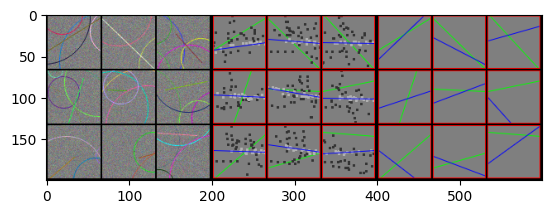

Storing snapshot. Validation loss: 43.81
Iteration:     71, DSAC Expected Loss: 53.36, DSAC Top Loss: 52.20, Direct Loss: 60.95, Time: 1.87s
Iteration:     72, DSAC Expected Loss: 53.94, DSAC Top Loss: 54.00, Direct Loss: 62.25, Time: 1.89s
Iteration:     73, DSAC Expected Loss: 58.22, DSAC Top Loss: 58.11, Direct Loss: 57.70, Time: 1.89s
Iteration:     74, DSAC Expected Loss: 57.31, DSAC Top Loss: 56.74, Direct Loss: 66.50, Time: 1.85s
Iteration:     75, DSAC Expected Loss: 54.02, DSAC Top Loss: 53.50, Direct Loss: 50.85, Time: 1.91s
Iteration:     76, DSAC Expected Loss: 56.87, DSAC Top Loss: 57.09, Direct Loss: 58.62, Time: 1.86s
Iteration:     77, DSAC Expected Loss: 56.50, DSAC Top Loss: 56.13, Direct Loss: 53.51, Time: 1.89s
Iteration:     78, DSAC Expected Loss: 59.89, DSAC Top Loss: 58.31, Direct Loss: 54.45, Time: 1.86s
Iteration:     79, DSAC Expected Loss: 54.01, DSAC Top Loss: 54.49, Direct Loss: 55.31, Time: 1.90s
Iteration:     80, DSAC Expected Loss: 54.20, DSAC Top Loss

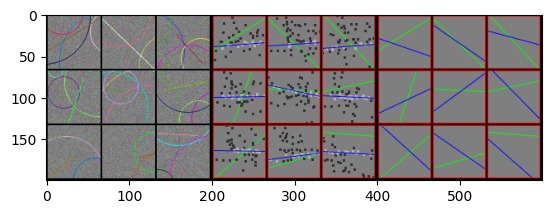

Storing snapshot. Validation loss: 43.42
Iteration:     81, DSAC Expected Loss: 53.63, DSAC Top Loss: 52.21, Direct Loss: 59.11, Time: 1.95s
Iteration:     82, DSAC Expected Loss: 54.21, DSAC Top Loss: 54.49, Direct Loss: 56.42, Time: 1.85s
Iteration:     83, DSAC Expected Loss: 52.84, DSAC Top Loss: 51.24, Direct Loss: 60.31, Time: 1.90s
Iteration:     84, DSAC Expected Loss: 61.16, DSAC Top Loss: 61.69, Direct Loss: 59.43, Time: 1.84s
Iteration:     85, DSAC Expected Loss: 54.86, DSAC Top Loss: 53.70, Direct Loss: 60.46, Time: 1.89s
Iteration:     86, DSAC Expected Loss: 50.96, DSAC Top Loss: 50.61, Direct Loss: 52.16, Time: 1.85s
Iteration:     87, DSAC Expected Loss: 58.11, DSAC Top Loss: 58.36, Direct Loss: 57.53, Time: 1.91s
Iteration:     88, DSAC Expected Loss: 52.23, DSAC Top Loss: 51.62, Direct Loss: 51.99, Time: 1.89s
Iteration:     89, DSAC Expected Loss: 51.97, DSAC Top Loss: 51.50, Direct Loss: 56.38, Time: 1.87s
Iteration:     90, DSAC Expected Loss: 58.39, DSAC Top Loss

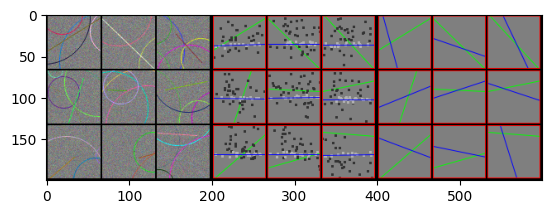

Storing snapshot. Validation loss: 45.78
Iteration:     91, DSAC Expected Loss: 47.53, DSAC Top Loss: 47.10, Direct Loss: 50.69, Time: 1.93s
Iteration:     92, DSAC Expected Loss: 45.62, DSAC Top Loss: 45.37, Direct Loss: 51.30, Time: 1.88s
Iteration:     93, DSAC Expected Loss: 49.43, DSAC Top Loss: 49.20, Direct Loss: 54.14, Time: 1.89s
Iteration:     94, DSAC Expected Loss: 54.58, DSAC Top Loss: 54.44, Direct Loss: 52.57, Time: 1.88s
Iteration:     95, DSAC Expected Loss: 56.35, DSAC Top Loss: 56.11, Direct Loss: 62.84, Time: 1.92s
Iteration:     96, DSAC Expected Loss: 53.71, DSAC Top Loss: 53.31, Direct Loss: 54.86, Time: 1.91s
Iteration:     97, DSAC Expected Loss: 53.14, DSAC Top Loss: 54.09, Direct Loss: 51.04, Time: 1.85s
Iteration:     98, DSAC Expected Loss: 57.42, DSAC Top Loss: 57.37, Direct Loss: 59.44, Time: 1.90s
Iteration:     99, DSAC Expected Loss: 59.11, DSAC Top Loss: 59.20, Direct Loss: 61.61, Time: 1.86s
Iteration:    100, DSAC Expected Loss: 61.02, DSAC Top Loss

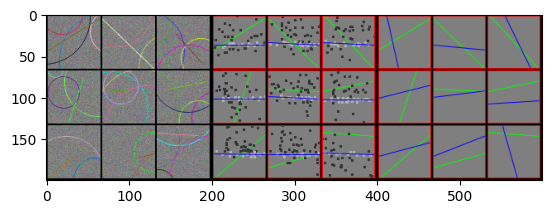

Storing snapshot. Validation loss: 45.39
Done without errors.


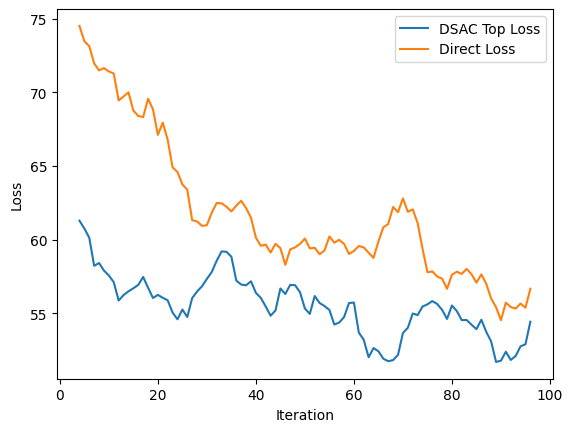

In [3]:
# train already implemented line fitting example and plot loss
params = default_params('line')
train_line_dsac(params)
plot_loss('./models/log_dsac_line.txt')

## Task 2
(1 point)

Implement the generation of synthetic circle images.

{'receptivefield': 65, 'capacity': 4, 'hypotheses': 64, 'inlierthreshold': 0.05, 'inlieralpha': 0.5, 'inlierbeta': 100.0, 'learningrate': 0.001, 'lrstep': 2500, 'lrstepoffset': 30000, 'batchsize': 32, 'trainiterations': 100, 'imagesize': 64, 'storeinterval': 10, 'valsize': 9, 'valthresh': 5, 'use_gpu': False, 'id': 'circle'}


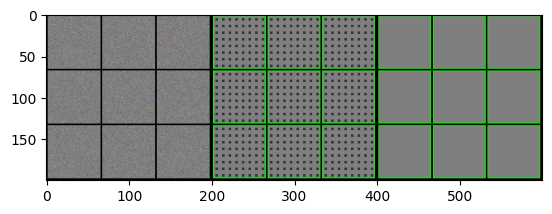

In [4]:
# load hyperparameter dictionary
params = default_params('circle')
print(params)

# initialize dataset
dataset = ICircleDataset(params['imagesize'], params['imagesize'])

# plot empty visualization
visualize_circle_dsac(params, dataset)

In [5]:
maxSlope = 10 # restrict the maximum slope of generated lines for stability
minLength = 20 # restrict the minimum length of line segments

class CircleDataset(ICircleDataset):
    def samples(self, n):
        '''
        Create new input images of random line segments and distractors along with ground truth parameters.

        n -- number of images to create
        '''
        data = np.zeros((n, self.imgH, self.imgW, 3), dtype=np.float32)
        data.fill(self.bg_clr)
        labels = np.ndarray((n, 3), dtype=np.float32)
        
        for i in range (0, n): # for each image
            # TODO:

            # You are given the tensors data and labels which you have to fill. 
            # Within this for loop, you work with data[i] and labels[i].

            # data[i]:
            #    draw a random number of random line segments in random colors, e.g. 2 to 5 lines
            #    draw one circle with a random center position, 
            #    a random radius in the range of 0.1 * self.imgW to 0.5 * self.imgW
            #    and a random color
            #    see the line fitting code for reference

            # labels[i]:
            #    should contain x and y of the circle center, and radius of the circle in this order
            #    the labels should be in normalized image coordinates, i.e. divided by the image size

            maxSlope = 10  # restrict the maximum slope of generated lines for stability
minLength = 20 # restrict the minimum length of line segments

class CircleDataset(ICircleDataset):
    def samples(self, n):
        '''
        Create new input images of random line segments and distractors along with ground truth parameters.

        n -- number of images to create
        '''
        data = np.zeros((n, self.imgH, self.imgW, 3), dtype=np.float32)
        data.fill(self.bg_clr)
        labels = np.ndarray((n, 3), dtype=np.float32)
        
        for i in range(n):  # for each image
            img = data[i]

            # ========= 1. 畫隨機線段 =========
            num_lines = random.randint(2, 5)

            for _ in range(num_lines):
                # 不斷嘗試直到找到符合長度 / 斜率條件的線
                tried = 0
                while True:
                    tried += 1
                    # 隨機兩個端點 (x, y)
                    x1 = random.randint(0, self.imgW - 1)
                    y1 = random.randint(0, self.imgH - 1)
                    x2 = random.randint(0, self.imgW - 1)
                    y2 = random.randint(0, self.imgH - 1)

                    dx = x2 - x1
                    dy = y2 - y1
                    length = math.sqrt(dx * dx + dy * dy)

                    # 長度太短就重抽
                    if length < minLength:
                        if tried > 20:
                            # 避免無限迴圈，硬畫這條
                            break
                        continue

                    # 計算斜率，避免 dx = 0 的除以 0
                    if abs(dx) < 1e-6:
                        slope = float('inf')
                    else:
                        slope = abs(dy / dx)

                    # 太陡 (slope > maxSlope) 的線不畫，重抽
                    if slope > maxSlope:
                        if tried > 20:
                            break
                        continue

                    # 這條線 OK
                    break

                # 使用反鋸齒線段繪製 (注意順序是 (row=y, col=x))
                rr, cc, val = line_aa(y1, x1, y2, x2)

                # 有些點可能會在邊界外，先做 clipping
                mask = (rr >= 0) & (rr < self.imgH) & (cc >= 0) & (cc < self.imgW)
                rr = rr[mask]
                cc = cc[mask]
                val = val[mask]

                # 隨機顏色 (RGB)
                line_color = np.random.rand(3).astype(np.float32)
                set_color(img, (rr, cc), line_color, alpha=val)

            # ========= 2. 畫圓 =========
            # 半徑 (pixel) 介於 0.1W ~ 0.5W
            r_min = 0.1 * self.imgW
            r_max = 0.5 * self.imgW
            r = random.uniform(r_min, r_max)

            # 圓心座標，讓整個圓大致在畫面內
            cx = random.uniform(r, self.imgW - 1 - r)
            cy = random.uniform(r, self.imgH - 1 - r)

            # 使用反鋸齒圓周，需整數 pixel
            cy_int = int(round(cy))
            cx_int = int(round(cx))
            r_int = int(round(r))

            rr, cc, val = circle_perimeter_aa(cy_int, cx_int, r_int)

            # 邊界檢查
            mask = (rr >= 0) & (rr < self.imgH) & (cc >= 0) & (cc < self.imgW)
            rr = rr[mask]
            cc = cc[mask]
            val = val[mask]

            circle_color = np.random.rand(3).astype(np.float32)
            set_color(img, (rr, cc), circle_color, alpha=val)

            # ========= 3. 設定 label (normalized coordinates) =========
            # x, y 中心點，半徑，都要正規化到 0~1
            labels[i, 0] = cx / float(self.imgW)   # center x normalized
            labels[i, 1] = cy / float(self.imgH)   # center y normalized
            labels[i, 2] = r  / float(self.imgW)   # radius normalized (通常用寬作基準)

            # ========= 4. 加 noise =========
            data[i] = random_noise(img, mode='speckle')

        return data, labels


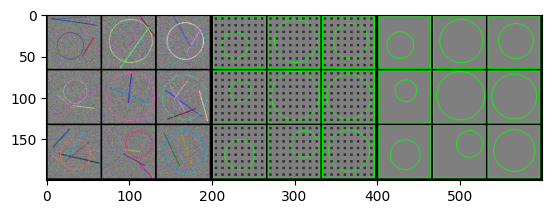

In [6]:
# load hyperparameter dictionary
params = default_params('circle')

# initialize dataset
dataset = CircleDataset(params['imagesize'], params['imagesize'])

# visualize your created dataset
visualize_circle_dsac(params, dataset)

## Task 3
(2 points)

Implement the circle loss function. The direct CNN prediction should work now. Run the code (~100 iterations) and plot the training loss.

In [7]:
class CircleLoss(ICircleLoss):
    def __call__(self, est, gt):
        '''
        Calculate the circle loss.

        est -- estimated circle, form: [cX, cY, r]
        gt -- ground truth circle, form: [cX, cY, r]
        '''
        # est, gt shape: (B, 3) or (3,)
        # 1. 中心差
        center_est = est[..., :2]
        center_gt  = gt[..., :2]
        diff_center = center_est - center_gt
        center_dist = torch.sqrt(torch.sum(diff_center ** 2, dim=-1) + 1e-8)

        # 2. 半徑差
        r_est = est[..., 2]
        r_gt  = gt[..., 2]
        r_dist = torch.abs(r_est - r_gt)

        # 3. 轉 pixel
        loss = (center_dist + r_dist) * self.image_size

        # 如果是 batch，就取 mean
        return loss.mean()


Iteration:      0, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 81.13, Time: 0.34s


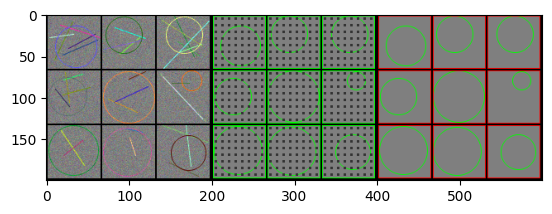

Storing snapshot. Validation loss: 0.00
Iteration:      1, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 70.02, Time: 0.35s
Iteration:      2, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 66.66, Time: 0.32s
Iteration:      3, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 56.14, Time: 0.30s
Iteration:      4, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 47.82, Time: 0.31s
Iteration:      5, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 41.51, Time: 0.31s
Iteration:      6, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 40.77, Time: 0.33s
Iteration:      7, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 39.39, Time: 0.31s
Iteration:      8, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 48.89, Time: 0.30s
Iteration:      9, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 44.35, Time: 0.30s
Iteration:     10, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

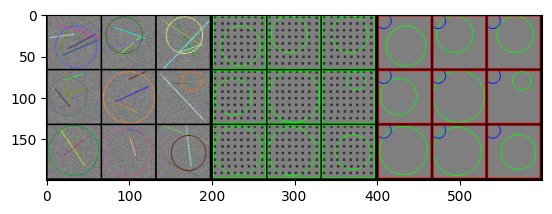

Storing snapshot. Validation loss: 0.00
Iteration:     11, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 37.61, Time: 0.35s
Iteration:     12, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 40.19, Time: 0.30s
Iteration:     13, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 49.33, Time: 0.30s
Iteration:     14, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 40.70, Time: 0.30s
Iteration:     15, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 37.76, Time: 0.30s
Iteration:     16, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 36.32, Time: 0.30s
Iteration:     17, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 34.54, Time: 0.30s
Iteration:     18, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 36.20, Time: 0.31s
Iteration:     19, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 37.74, Time: 0.30s
Iteration:     20, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

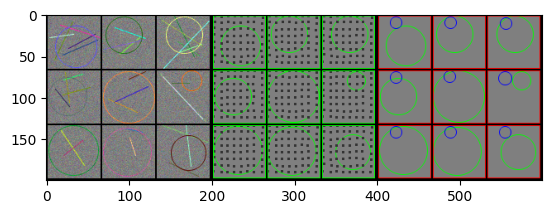

Storing snapshot. Validation loss: 0.00
Iteration:     21, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 33.54, Time: 0.40s
Iteration:     22, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 28.49, Time: 0.31s
Iteration:     23, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 32.51, Time: 0.31s
Iteration:     24, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 28.74, Time: 0.30s
Iteration:     25, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 30.97, Time: 0.30s
Iteration:     26, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 30.19, Time: 0.30s
Iteration:     27, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 25.00, Time: 0.30s
Iteration:     28, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 33.14, Time: 0.30s
Iteration:     29, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 28.38, Time: 0.31s
Iteration:     30, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

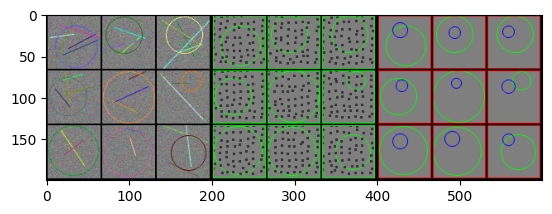

Storing snapshot. Validation loss: 0.00
Iteration:     31, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 24.73, Time: 0.34s
Iteration:     32, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 27.58, Time: 0.30s
Iteration:     33, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 24.26, Time: 0.30s
Iteration:     34, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 25.43, Time: 0.30s
Iteration:     35, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 22.33, Time: 0.32s
Iteration:     36, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 23.75, Time: 0.30s
Iteration:     37, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 22.96, Time: 0.31s
Iteration:     38, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 23.16, Time: 0.30s
Iteration:     39, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.68, Time: 0.30s
Iteration:     40, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

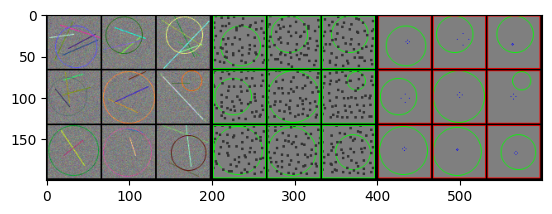

Storing snapshot. Validation loss: 0.00
Iteration:     41, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.53, Time: 0.35s
Iteration:     42, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 23.09, Time: 0.31s
Iteration:     43, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 23.74, Time: 0.30s
Iteration:     44, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.46, Time: 0.30s
Iteration:     45, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.08, Time: 0.31s
Iteration:     46, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 23.38, Time: 0.31s
Iteration:     47, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.94, Time: 0.31s
Iteration:     48, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 19.65, Time: 0.31s
Iteration:     49, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 16.91, Time: 0.30s
Iteration:     50, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

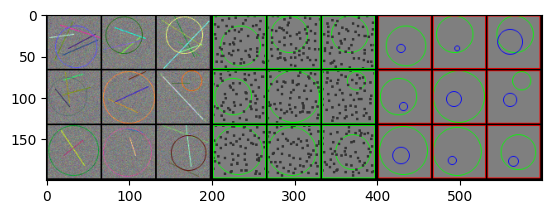

Storing snapshot. Validation loss: 0.00
Iteration:     51, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.23, Time: 0.38s
Iteration:     52, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.52, Time: 0.31s
Iteration:     53, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.40, Time: 0.30s
Iteration:     54, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.65, Time: 0.30s
Iteration:     55, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 19.59, Time: 0.30s
Iteration:     56, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.50, Time: 0.31s
Iteration:     57, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.40, Time: 0.31s
Iteration:     58, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.54, Time: 0.31s
Iteration:     59, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.23, Time: 0.30s
Iteration:     60, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

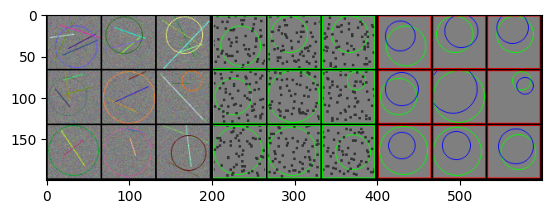

Storing snapshot. Validation loss: 0.00
Iteration:     61, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.66, Time: 0.35s
Iteration:     62, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 22.64, Time: 0.30s
Iteration:     63, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 19.24, Time: 0.30s
Iteration:     64, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.80, Time: 0.30s
Iteration:     65, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 14.10, Time: 0.31s
Iteration:     66, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.67, Time: 0.31s
Iteration:     67, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.28, Time: 0.30s
Iteration:     68, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.62, Time: 0.32s
Iteration:     69, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 22.06, Time: 0.30s
Iteration:     70, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

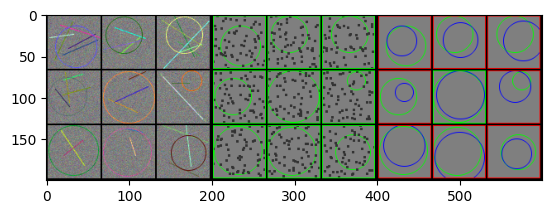

Storing snapshot. Validation loss: 0.00
Iteration:     71, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.73, Time: 0.34s
Iteration:     72, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 16.67, Time: 0.31s
Iteration:     73, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.80, Time: 0.31s
Iteration:     74, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 16.31, Time: 0.30s
Iteration:     75, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 16.59, Time: 0.30s
Iteration:     76, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.17, Time: 0.31s
Iteration:     77, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.42, Time: 0.30s
Iteration:     78, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.24, Time: 0.30s
Iteration:     79, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 16.48, Time: 0.31s
Iteration:     80, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

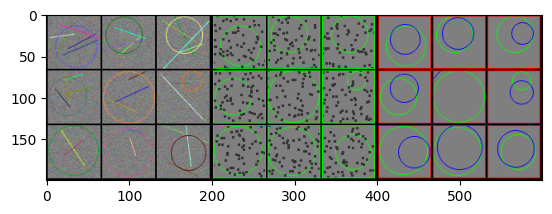

Storing snapshot. Validation loss: 0.00
Iteration:     81, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.00, Time: 0.33s
Iteration:     82, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.23, Time: 0.31s
Iteration:     83, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 19.38, Time: 0.31s
Iteration:     84, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 13.16, Time: 0.30s
Iteration:     85, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.28, Time: 0.31s
Iteration:     86, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.28, Time: 0.30s
Iteration:     87, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 19.40, Time: 0.31s
Iteration:     88, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.56, Time: 0.30s
Iteration:     89, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 20.85, Time: 0.30s
Iteration:     90, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

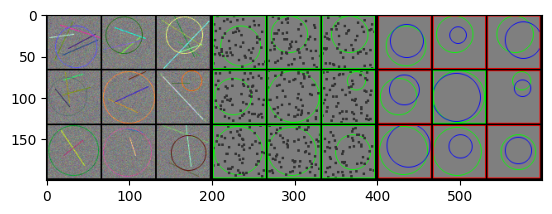

Storing snapshot. Validation loss: 0.00
Iteration:     91, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 15.36, Time: 0.36s
Iteration:     92, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.30, Time: 0.30s
Iteration:     93, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.00, Time: 0.31s
Iteration:     94, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 18.29, Time: 0.31s
Iteration:     95, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 14.73, Time: 0.30s
Iteration:     96, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 21.94, Time: 0.30s
Iteration:     97, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 17.63, Time: 0.30s
Iteration:     98, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 15.98, Time: 0.29s
Iteration:     99, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss: 16.33, Time: 0.31s
Iteration:    100, DSAC Expected Loss: 0.00, DSAC Top Loss: 0.00, Direct Loss:

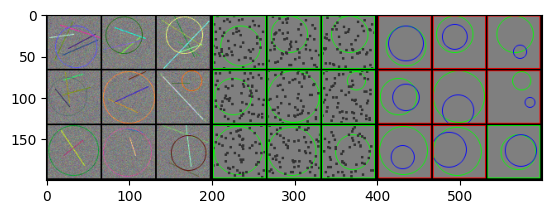

Storing snapshot. Validation loss: 0.00
Done without errors.


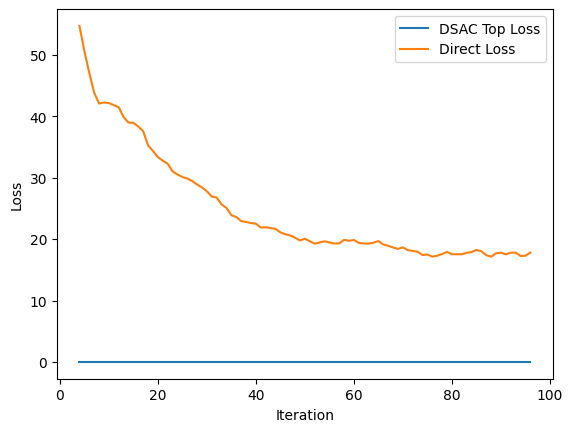

In [8]:
# load hyperparameter dictionary
params = default_params('circle')

# initialize dataset
dataset = CircleDataset(params['imagesize'], params['imagesize'])

# initialize loss function
loss = CircleLoss(params['imagesize'])

# train and plot loss
train_circle_dsac(params, dataset, loss)
plot_loss('./models/log_dsac_circle.txt')

## Task 4
(5 + 1 points)

Implement DSAC circle fitting.
1. Implement hypothesis sampling. (1 point)
-- Fill in the blank method `_sample_hyp`

2. Implement soft inlier count. (2 points)
-- Fill in the blank method `_soft_inlier_count`

3. Implement refinement with hard inliers (2 point)
-- Fill in the blank method `_refine_hyp`

4. Bonus: Implement refinement with soft inliers (+1 point)

In [9]:
class CircleDSAC(ICircleDSAC):
    def __init__(self, hyps, inlier_thresh, inlier_beta, inlier_alpha, loss_function):
        ICircleDSAC.__init__(self, hyps, inlier_thresh, inlier_beta, inlier_alpha, loss_function)
    
    def _sample_hyp(self, x, y):
        """
        Sample a circle hypothesis from 3 random points.
        Returns (cX, cY, r, valid_flag)
        """
        max_tries = 1000
        n = x.size(0)

        if n < 3:
            return 0, 0, 0, False

        for _ in range(max_tries):
            # 隨機選三個不同的點
            idx = torch.randperm(n)[:3]
            x1, x2, x3 = x[idx[0]], x[idx[1]], x[idx[2]]
            y1, y2, y3 = y[idx[0]], y[idx[1]], y[idx[2]]

            # 用線性代數公式計算圓心
            # 參考推導：
            # A * cX + B * cY = E
            # C * cX + D * cY = F
            A = x1 - x3
            B = y1 - y3
            C = x2 - x3
            D = y2 - y3

            det = A * D - B * C
            if torch.abs(det) < 1e-6:
                # 三點幾乎共線，重抽
                continue

            E = (x1**2 - x3**2 + y1**2 - y3**2) / 2.0
            F = (x2**2 - x3**2 + y2**2 - y3**2) / 2.0

            cX = (D * E - B * F) / det
            cY = (-C * E + A * F) / det

            # 半徑
            r = torch.sqrt((x1 - cX) ** 2 + (y1 - cY) ** 2 + 1e-8)

            # sanity check: 參數是 0~1 的 normalized，半徑不應該超過 1
            if r <= 1.0:
                return cX, cY, r, True

        # 1000 次都失敗
        return 0, 0, 0, False
        
    def _soft_inlier_count(self, cX, cY, r, x, y):
        """
        Soft inlier count for a given circle and a given set of points.
        """
        # 點到圓心距離
        dx = x - cX
        dy = y - cY
        dist_center = torch.sqrt(dx * dx + dy * dy + 1e-8)

        # 和理想半徑的差距
        dist_circle = torch.abs(dist_center - r)

        # soft inlier score（跟 line DSAC 一樣的 sigmoid）
        scores = torch.sigmoid(self.inlier_beta * (self.inlier_thresh - dist_circle))

        total_score = torch.sum(scores)
        return total_score, scores
    
    def _refine_hyp(self, x, y, weights):
        """
        Refinement by (weighted) least squares fit.
        """
        # 如果想用 hard inlier，可以打開這三行：
        # mask = weights > 0.5
        # x = x[mask]
        # y = y[mask]
        # w = weights[mask]

        w = weights

        # 至少要有 3 個點才能 fit 圓
        if x.numel() < 3:
            return 0, 0, 0

        # 構造 A, b： 2ax + 2by + c = x^2 + y^2
        A0 = 2.0 * x
        A1 = 2.0 * y
        A2 = torch.ones_like(x)
        A = torch.stack([A0, A1, A2], dim=1)   # (N, 3)

        b_vec = x * x + y * y                  # (N,)

        # soft inlier 權重（加分題）
        w_clamped = torch.clamp(w, min=1e-8)
        w_sqrt = torch.sqrt(w_clamped)

        A_w = A * w_sqrt.unsqueeze(1)          # (N,3)
        b_w = b_vec * w_sqrt                   # (N,)

        # normal equations: (A^T A) p = A^T b
        ATA = A_w.t().mm(A_w)                  # (3,3)
        ATb = A_w.t().mv(b_w)                  # (3,)

        # 解 p = [a, b, c]^T
        p = torch.linalg.solve(ATA, ATb)

        a = p[0]
        b_param = p[1]
        c_param = p[2]

        cX = a
        cY = b_param
        r = torch.sqrt(torch.clamp(a * a + b_param * b_param + c_param, min=1e-8))

        return cX, cY, r


Iteration:      0, DSAC Expected Loss: 26.38, DSAC Top Loss: 24.70, Direct Loss: 65.37, Time: 2.40s


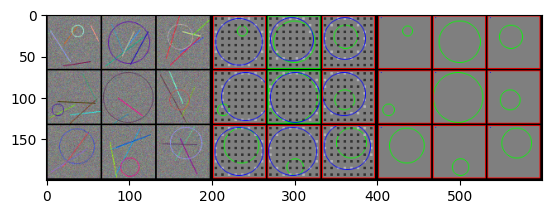

Storing snapshot. Validation loss: 22.42
Iteration:      1, DSAC Expected Loss: 21.24, DSAC Top Loss: 19.28, Direct Loss: 60.96, Time: 2.36s
Iteration:      2, DSAC Expected Loss: 20.77, DSAC Top Loss: 19.22, Direct Loss: 51.84, Time: 2.30s
Iteration:      3, DSAC Expected Loss: 19.04, DSAC Top Loss: 17.87, Direct Loss: 51.01, Time: 2.27s
Iteration:      4, DSAC Expected Loss: 19.63, DSAC Top Loss: 19.05, Direct Loss: 47.65, Time: 2.27s
Iteration:      5, DSAC Expected Loss: 20.15, DSAC Top Loss: 19.23, Direct Loss: 44.20, Time: 2.26s
Iteration:      6, DSAC Expected Loss: 16.75, DSAC Top Loss: 14.67, Direct Loss: 39.73, Time: 2.27s
Iteration:      7, DSAC Expected Loss: 18.61, DSAC Top Loss: 17.70, Direct Loss: 37.08, Time: 2.19s
Iteration:      8, DSAC Expected Loss: 22.29, DSAC Top Loss: 22.60, Direct Loss: 47.71, Time: 2.25s
Iteration:      9, DSAC Expected Loss: 18.35, DSAC Top Loss: 17.60, Direct Loss: 46.68, Time: 2.25s
Iteration:     10, DSAC Expected Loss: 20.20, DSAC Top Loss

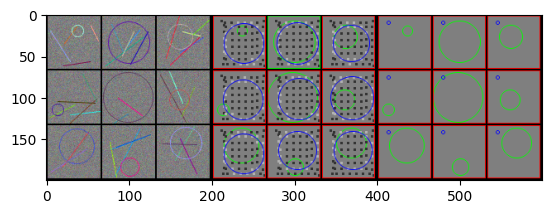

Storing snapshot. Validation loss: 22.00
Iteration:     11, DSAC Expected Loss: 16.25, DSAC Top Loss: 14.94, Direct Loss: 43.82, Time: 2.30s
Iteration:     12, DSAC Expected Loss: 17.18, DSAC Top Loss: 16.87, Direct Loss: 39.92, Time: 2.26s
Iteration:     13, DSAC Expected Loss: 19.65, DSAC Top Loss: 18.32, Direct Loss: 40.75, Time: 2.21s
Iteration:     14, DSAC Expected Loss: 18.61, DSAC Top Loss: 15.55, Direct Loss: 33.91, Time: 2.27s
Iteration:     15, DSAC Expected Loss: 21.64, DSAC Top Loss: 19.06, Direct Loss: 33.73, Time: 2.25s
Iteration:     16, DSAC Expected Loss: 22.14, DSAC Top Loss: 20.04, Direct Loss: 37.87, Time: 2.26s
Iteration:     17, DSAC Expected Loss: 21.38, DSAC Top Loss: 19.03, Direct Loss: 37.62, Time: 2.30s
Iteration:     18, DSAC Expected Loss: 18.55, DSAC Top Loss: 16.70, Direct Loss: 28.64, Time: 2.22s
Iteration:     19, DSAC Expected Loss: 17.77, DSAC Top Loss: 16.45, Direct Loss: 31.41, Time: 2.28s
Iteration:     20, DSAC Expected Loss: 19.55, DSAC Top Loss

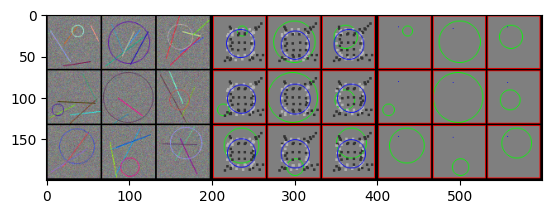

Storing snapshot. Validation loss: 18.51
Iteration:     21, DSAC Expected Loss: 19.91, DSAC Top Loss: 19.08, Direct Loss: 32.88, Time: 2.31s
Iteration:     22, DSAC Expected Loss: 16.46, DSAC Top Loss: 14.70, Direct Loss: 33.78, Time: 2.30s
Iteration:     23, DSAC Expected Loss: 17.17, DSAC Top Loss: 16.00, Direct Loss: 29.89, Time: 2.28s
Iteration:     24, DSAC Expected Loss: 17.55, DSAC Top Loss: 16.54, Direct Loss: 31.36, Time: 2.21s
Iteration:     25, DSAC Expected Loss: 16.71, DSAC Top Loss: 16.22, Direct Loss: 29.40, Time: 2.28s
Iteration:     26, DSAC Expected Loss: 16.53, DSAC Top Loss: 15.56, Direct Loss: 28.80, Time: 2.24s
Iteration:     27, DSAC Expected Loss: 16.34, DSAC Top Loss: 15.93, Direct Loss: 29.33, Time: 2.30s
Iteration:     28, DSAC Expected Loss: 15.86, DSAC Top Loss: 14.61, Direct Loss: 24.77, Time: 2.23s
Iteration:     29, DSAC Expected Loss: 17.61, DSAC Top Loss: 16.80, Direct Loss: 26.75, Time: 2.28s
Iteration:     30, DSAC Expected Loss: 18.90, DSAC Top Loss

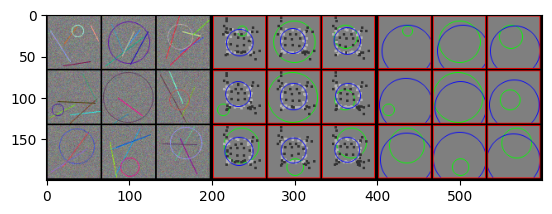

Storing snapshot. Validation loss: 17.09
Iteration:     31, DSAC Expected Loss: 15.87, DSAC Top Loss: 14.43, Direct Loss: 20.56, Time: 2.33s
Iteration:     32, DSAC Expected Loss: 15.11, DSAC Top Loss: 13.27, Direct Loss: 27.08, Time: 2.28s
Iteration:     33, DSAC Expected Loss: 21.06, DSAC Top Loss: 20.61, Direct Loss: 31.85, Time: 2.31s
Iteration:     34, DSAC Expected Loss: 16.64, DSAC Top Loss: 15.07, Direct Loss: 23.46, Time: 2.27s
Iteration:     35, DSAC Expected Loss: 18.91, DSAC Top Loss: 18.08, Direct Loss: 26.45, Time: 2.22s
Iteration:     36, DSAC Expected Loss: 14.54, DSAC Top Loss: 14.13, Direct Loss: 25.69, Time: 2.26s
Iteration:     37, DSAC Expected Loss: 15.66, DSAC Top Loss: 15.26, Direct Loss: 22.92, Time: 2.28s
Iteration:     38, DSAC Expected Loss: 14.20, DSAC Top Loss: 12.89, Direct Loss: 21.42, Time: 2.27s
Iteration:     39, DSAC Expected Loss: 15.47, DSAC Top Loss: 14.12, Direct Loss: 18.80, Time: 2.20s
Iteration:     40, DSAC Expected Loss: 17.70, DSAC Top Loss

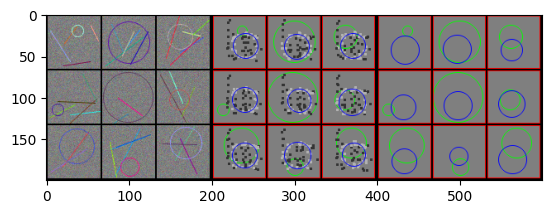

Storing snapshot. Validation loss: 21.10
Iteration:     41, DSAC Expected Loss: 17.20, DSAC Top Loss: 15.79, Direct Loss: 24.60, Time: 2.39s
Iteration:     42, DSAC Expected Loss: 18.47, DSAC Top Loss: 18.29, Direct Loss: 21.33, Time: 2.29s
Iteration:     43, DSAC Expected Loss: 16.02, DSAC Top Loss: 15.34, Direct Loss: 20.40, Time: 2.28s
Iteration:     44, DSAC Expected Loss: 14.80, DSAC Top Loss: 13.74, Direct Loss: 22.03, Time: 2.31s
Iteration:     45, DSAC Expected Loss: 17.12, DSAC Top Loss: 16.69, Direct Loss: 21.42, Time: 2.23s
Iteration:     46, DSAC Expected Loss: 16.82, DSAC Top Loss: 16.43, Direct Loss: 22.15, Time: 2.26s
Iteration:     47, DSAC Expected Loss: 15.96, DSAC Top Loss: 15.55, Direct Loss: 22.44, Time: 2.25s
Iteration:     48, DSAC Expected Loss: 15.13, DSAC Top Loss: 14.59, Direct Loss: 22.69, Time: 2.26s
Iteration:     49, DSAC Expected Loss: 16.06, DSAC Top Loss: 16.20, Direct Loss: 21.61, Time: 2.25s
Iteration:     50, DSAC Expected Loss: 15.08, DSAC Top Loss

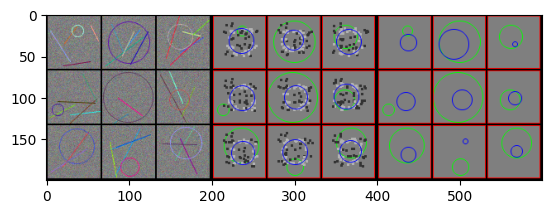

Storing snapshot. Validation loss: 17.98
Iteration:     51, DSAC Expected Loss: 14.40, DSAC Top Loss: 13.93, Direct Loss: 20.26, Time: 2.24s
Iteration:     52, DSAC Expected Loss: 15.09, DSAC Top Loss: 14.42, Direct Loss: 21.18, Time: 2.30s
Iteration:     53, DSAC Expected Loss: 15.03, DSAC Top Loss: 15.06, Direct Loss: 19.20, Time: 2.30s
Iteration:     54, DSAC Expected Loss: 15.42, DSAC Top Loss: 15.05, Direct Loss: 20.58, Time: 2.28s
Iteration:     55, DSAC Expected Loss: 17.18, DSAC Top Loss: 16.96, Direct Loss: 25.08, Time: 2.27s
Iteration:     56, DSAC Expected Loss: 14.86, DSAC Top Loss: 14.15, Direct Loss: 17.25, Time: 2.28s
Iteration:     57, DSAC Expected Loss: 15.25, DSAC Top Loss: 14.51, Direct Loss: 20.33, Time: 2.24s
Iteration:     58, DSAC Expected Loss: 16.04, DSAC Top Loss: 15.74, Direct Loss: 17.77, Time: 2.27s
Iteration:     59, DSAC Expected Loss: 15.52, DSAC Top Loss: 15.31, Direct Loss: 18.66, Time: 2.26s
Iteration:     60, DSAC Expected Loss: 14.90, DSAC Top Loss

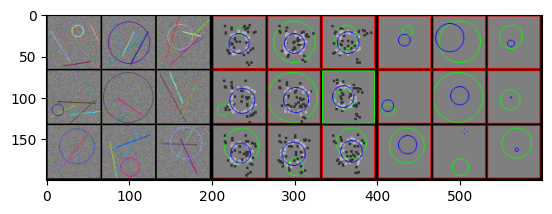

Storing snapshot. Validation loss: 17.34
Iteration:     61, DSAC Expected Loss: 15.24, DSAC Top Loss: 14.48, Direct Loss: 18.34, Time: 2.35s
Iteration:     62, DSAC Expected Loss: 15.18, DSAC Top Loss: 14.59, Direct Loss: 17.88, Time: 2.28s
Iteration:     63, DSAC Expected Loss: 16.36, DSAC Top Loss: 14.90, Direct Loss: 19.27, Time: 2.23s
Iteration:     64, DSAC Expected Loss: 15.04, DSAC Top Loss: 14.11, Direct Loss: 18.98, Time: 2.27s
Iteration:     65, DSAC Expected Loss: 15.77, DSAC Top Loss: 14.96, Direct Loss: 20.05, Time: 2.29s
Iteration:     66, DSAC Expected Loss: 14.90, DSAC Top Loss: 14.01, Direct Loss: 19.61, Time: 2.28s
Iteration:     67, DSAC Expected Loss: 14.31, DSAC Top Loss: 13.61, Direct Loss: 17.13, Time: 2.24s
Iteration:     68, DSAC Expected Loss: 14.29, DSAC Top Loss: 13.77, Direct Loss: 16.36, Time: 2.27s
Iteration:     69, DSAC Expected Loss: 15.87, DSAC Top Loss: 15.59, Direct Loss: 21.33, Time: 2.28s
Iteration:     70, DSAC Expected Loss: 14.78, DSAC Top Loss

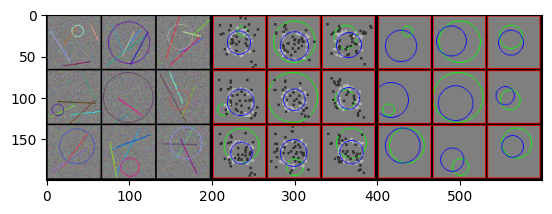

Storing snapshot. Validation loss: 17.86
Iteration:     71, DSAC Expected Loss: 17.02, DSAC Top Loss: 16.42, Direct Loss: 18.05, Time: 2.34s
Iteration:     72, DSAC Expected Loss: 16.57, DSAC Top Loss: 16.19, Direct Loss: 18.04, Time: 2.25s
Iteration:     73, DSAC Expected Loss: 15.02, DSAC Top Loss: 14.42, Direct Loss: 17.41, Time: 2.27s
Iteration:     74, DSAC Expected Loss: 18.27, DSAC Top Loss: 17.99, Direct Loss: 19.56, Time: 2.21s
Iteration:     75, DSAC Expected Loss: 16.76, DSAC Top Loss: 17.03, Direct Loss: 17.74, Time: 2.28s
Iteration:     76, DSAC Expected Loss: 17.65, DSAC Top Loss: 17.29, Direct Loss: 17.92, Time: 2.27s
Iteration:     77, DSAC Expected Loss: 17.13, DSAC Top Loss: 16.17, Direct Loss: 17.44, Time: 2.26s
Iteration:     78, DSAC Expected Loss: 13.88, DSAC Top Loss: 13.78, Direct Loss: 16.24, Time: 2.23s
Iteration:     79, DSAC Expected Loss: 14.63, DSAC Top Loss: 13.06, Direct Loss: 16.37, Time: 2.28s
Iteration:     80, DSAC Expected Loss: 16.27, DSAC Top Loss

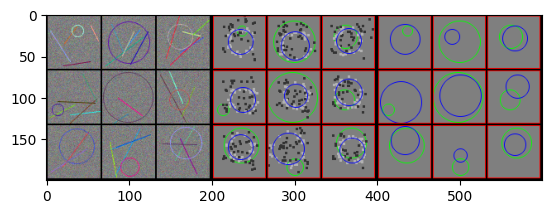

Storing snapshot. Validation loss: 18.40
Iteration:     81, DSAC Expected Loss: 16.08, DSAC Top Loss: 15.50, Direct Loss: 19.07, Time: 2.29s
Iteration:     82, DSAC Expected Loss: 15.95, DSAC Top Loss: 14.53, Direct Loss: 19.22, Time: 2.28s
Iteration:     83, DSAC Expected Loss: 17.12, DSAC Top Loss: 16.61, Direct Loss: 19.64, Time: 2.26s
Iteration:     84, DSAC Expected Loss: 14.69, DSAC Top Loss: 13.88, Direct Loss: 16.57, Time: 2.23s
Iteration:     85, DSAC Expected Loss: 15.97, DSAC Top Loss: 15.53, Direct Loss: 18.73, Time: 2.25s
Iteration:     86, DSAC Expected Loss: 16.65, DSAC Top Loss: 15.94, Direct Loss: 17.85, Time: 2.26s
Iteration:     87, DSAC Expected Loss: 15.99, DSAC Top Loss: 15.55, Direct Loss: 16.46, Time: 2.27s
Iteration:     88, DSAC Expected Loss: 14.27, DSAC Top Loss: 13.88, Direct Loss: 17.48, Time: 2.27s
Iteration:     89, DSAC Expected Loss: 13.70, DSAC Top Loss: 12.57, Direct Loss: 15.25, Time: 2.26s
Iteration:     90, DSAC Expected Loss: 14.51, DSAC Top Loss

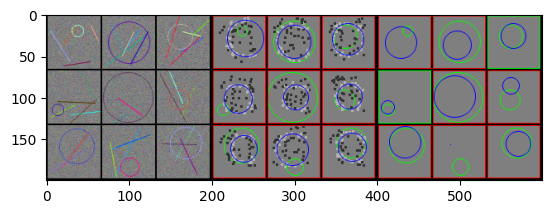

Storing snapshot. Validation loss: 16.48
Iteration:     91, DSAC Expected Loss: 15.77, DSAC Top Loss: 15.00, Direct Loss: 16.03, Time: 2.28s
Iteration:     92, DSAC Expected Loss: 11.76, DSAC Top Loss: 11.58, Direct Loss: 16.33, Time: 2.27s
Iteration:     93, DSAC Expected Loss: 15.28, DSAC Top Loss: 15.06, Direct Loss: 19.34, Time: 2.27s
Iteration:     94, DSAC Expected Loss: 11.76, DSAC Top Loss: 10.95, Direct Loss: 13.96, Time: 2.25s
Iteration:     95, DSAC Expected Loss: 11.73, DSAC Top Loss: 10.74, Direct Loss: 13.30, Time: 2.29s
Iteration:     96, DSAC Expected Loss: 13.68, DSAC Top Loss: 13.46, Direct Loss: 17.73, Time: 2.20s
Iteration:     97, DSAC Expected Loss: 13.35, DSAC Top Loss: 12.51, Direct Loss: 12.41, Time: 2.29s
Iteration:     98, DSAC Expected Loss: 12.79, DSAC Top Loss: 11.51, Direct Loss: 14.90, Time: 2.24s
Iteration:     99, DSAC Expected Loss: 14.12, DSAC Top Loss: 12.86, Direct Loss: 17.93, Time: 2.30s
Iteration:    100, DSAC Expected Loss: 16.73, DSAC Top Loss

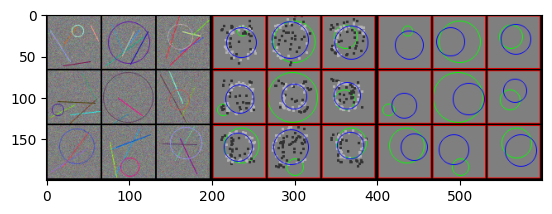

Storing snapshot. Validation loss: 17.85
Done without errors.


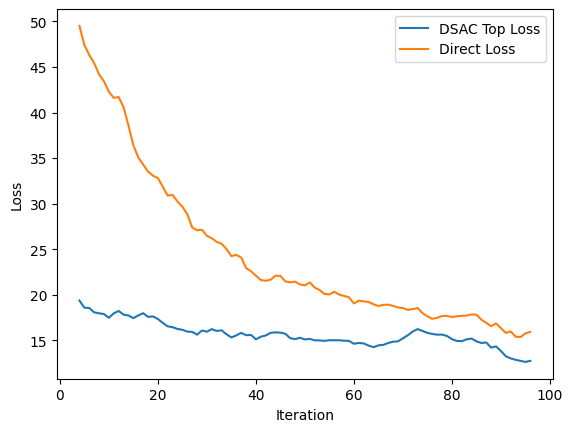

In [10]:
# load hyperparameter dictionary
params = default_params('circle')

# initialize dataset
dataset = CircleDataset(params['imagesize'], params['imagesize'])

# initialize loss function
loss = CircleLoss(params['imagesize'])

# initialize DSAC
dsac = CircleDSAC(params['hypotheses'], params['inlierthreshold'], params['inlierbeta'], params['inlieralpha'], loss)

# train and plot losses
train_circle_dsac(params, dataset, loss, dsac)
plot_loss('./models/log_dsac_circle.txt')

## Task 5
(priceless)

Run everything, plot losses, play with parameters, look at images

In [11]:
# load default parameters
params = default_params('circle')

# TODO: play around with parameter dictionary


# initialize dataset
dataset = CircleDataset(params['imagesize'], params['imagesize'])

# initialize loss function
loss = CircleLoss(params['imagesize'])

# initialize DSAC
dsac = CircleDSAC(params['hypotheses'], params['inlierthreshold'], params['inlierbeta'], params['inlieralpha'], loss)

In [12]:
print(params)

{'receptivefield': 65, 'capacity': 4, 'hypotheses': 64, 'inlierthreshold': 0.05, 'inlieralpha': 0.5, 'inlierbeta': 100.0, 'learningrate': 0.001, 'lrstep': 2500, 'lrstepoffset': 30000, 'batchsize': 32, 'trainiterations': 100, 'imagesize': 64, 'storeinterval': 10, 'valsize': 9, 'valthresh': 5, 'use_gpu': False, 'id': 'circle'}


Iteration:      0, DSAC Expected Loss: 22.68, DSAC Top Loss: 19.90, Direct Loss: 78.69, Time: 2.33s


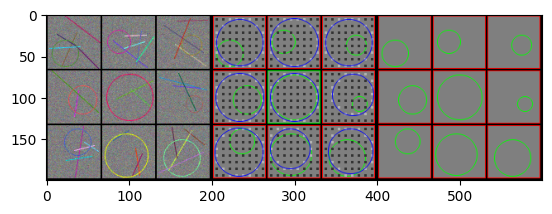

Storing snapshot. Validation loss: 20.88
Iteration:      1, DSAC Expected Loss: 20.03, DSAC Top Loss: 19.51, Direct Loss: 71.33, Time: 2.29s
Iteration:      2, DSAC Expected Loss: 19.12, DSAC Top Loss: 18.14, Direct Loss: 66.71, Time: 2.26s
Iteration:      3, DSAC Expected Loss: 21.17, DSAC Top Loss: 20.18, Direct Loss: 52.30, Time: 2.26s
Iteration:      4, DSAC Expected Loss: 17.00, DSAC Top Loss: 15.13, Direct Loss: 44.74, Time: 2.26s
Iteration:      5, DSAC Expected Loss: 15.89, DSAC Top Loss: 14.21, Direct Loss: 43.73, Time: 2.26s
Iteration:      6, DSAC Expected Loss: 17.77, DSAC Top Loss: 17.27, Direct Loss: 42.79, Time: 2.25s
Iteration:      7, DSAC Expected Loss: 18.36, DSAC Top Loss: 17.00, Direct Loss: 48.97, Time: 2.21s
Iteration:      8, DSAC Expected Loss: 15.65, DSAC Top Loss: 14.86, Direct Loss: 41.43, Time: 2.30s
Iteration:      9, DSAC Expected Loss: 19.54, DSAC Top Loss: 18.24, Direct Loss: 43.42, Time: 2.27s
Iteration:     10, DSAC Expected Loss: 21.32, DSAC Top Loss

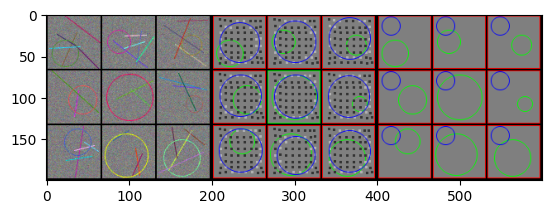

Storing snapshot. Validation loss: 18.58
Iteration:     11, DSAC Expected Loss: 16.56, DSAC Top Loss: 14.92, Direct Loss: 39.32, Time: 2.30s
Iteration:     12, DSAC Expected Loss: 16.09, DSAC Top Loss: 15.01, Direct Loss: 39.25, Time: 2.20s
Iteration:     13, DSAC Expected Loss: 14.28, DSAC Top Loss: 13.82, Direct Loss: 39.49, Time: 2.29s
Iteration:     14, DSAC Expected Loss: 15.86, DSAC Top Loss: 15.46, Direct Loss: 37.36, Time: 2.24s
Iteration:     15, DSAC Expected Loss: 18.43, DSAC Top Loss: 17.31, Direct Loss: 36.74, Time: 2.28s
Iteration:     16, DSAC Expected Loss: 15.79, DSAC Top Loss: 14.64, Direct Loss: 35.17, Time: 2.22s
Iteration:     17, DSAC Expected Loss: 17.25, DSAC Top Loss: 16.29, Direct Loss: 33.00, Time: 2.26s
Iteration:     18, DSAC Expected Loss: 16.65, DSAC Top Loss: 15.61, Direct Loss: 31.29, Time: 2.24s
Iteration:     19, DSAC Expected Loss: 17.81, DSAC Top Loss: 15.16, Direct Loss: 35.16, Time: 2.26s
Iteration:     20, DSAC Expected Loss: 16.51, DSAC Top Loss

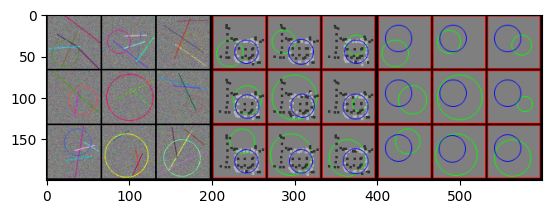

Storing snapshot. Validation loss: 19.49
Iteration:     21, DSAC Expected Loss: 16.89, DSAC Top Loss: 16.22, Direct Loss: 29.89, Time: 2.28s
Iteration:     22, DSAC Expected Loss: 15.67, DSAC Top Loss: 14.65, Direct Loss: 30.00, Time: 2.19s
Iteration:     23, DSAC Expected Loss: 16.80, DSAC Top Loss: 16.67, Direct Loss: 29.20, Time: 2.28s
Iteration:     24, DSAC Expected Loss: 15.55, DSAC Top Loss: 14.70, Direct Loss: 35.42, Time: 2.25s
Iteration:     25, DSAC Expected Loss: 16.28, DSAC Top Loss: 14.31, Direct Loss: 29.30, Time: 2.25s
Iteration:     26, DSAC Expected Loss: 15.32, DSAC Top Loss: 14.20, Direct Loss: 24.18, Time: 2.26s
Iteration:     27, DSAC Expected Loss: 15.24, DSAC Top Loss: 14.48, Direct Loss: 22.60, Time: 2.21s
Iteration:     28, DSAC Expected Loss: 15.15, DSAC Top Loss: 14.97, Direct Loss: 30.58, Time: 2.26s
Iteration:     29, DSAC Expected Loss: 15.20, DSAC Top Loss: 14.78, Direct Loss: 24.61, Time: 2.24s
Iteration:     30, DSAC Expected Loss: 15.97, DSAC Top Loss

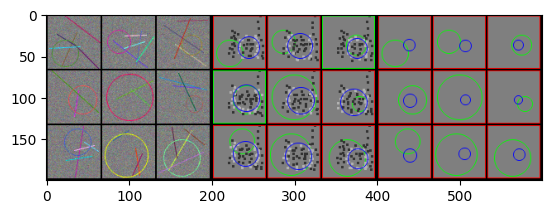

Storing snapshot. Validation loss: 16.40
Iteration:     31, DSAC Expected Loss: 14.71, DSAC Top Loss: 14.62, Direct Loss: 25.75, Time: 2.28s
Iteration:     32, DSAC Expected Loss: 15.96, DSAC Top Loss: 15.52, Direct Loss: 25.67, Time: 2.27s
Iteration:     33, DSAC Expected Loss: 14.98, DSAC Top Loss: 14.64, Direct Loss: 22.39, Time: 2.25s
Iteration:     34, DSAC Expected Loss: 16.17, DSAC Top Loss: 15.36, Direct Loss: 25.66, Time: 2.27s
Iteration:     35, DSAC Expected Loss: 15.22, DSAC Top Loss: 14.52, Direct Loss: 29.04, Time: 2.25s
Iteration:     36, DSAC Expected Loss: 17.13, DSAC Top Loss: 16.42, Direct Loss: 27.64, Time: 2.26s
Iteration:     37, DSAC Expected Loss: 14.75, DSAC Top Loss: 13.81, Direct Loss: 21.81, Time: 2.23s
Iteration:     38, DSAC Expected Loss: 13.40, DSAC Top Loss: 13.44, Direct Loss: 21.68, Time: 2.28s
Iteration:     39, DSAC Expected Loss: 13.92, DSAC Top Loss: 13.03, Direct Loss: 20.15, Time: 2.25s
Iteration:     40, DSAC Expected Loss: 15.32, DSAC Top Loss

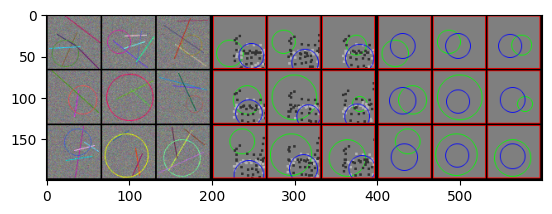

Storing snapshot. Validation loss: 30.09
Iteration:     41, DSAC Expected Loss: 18.22, DSAC Top Loss: 17.48, Direct Loss: 21.64, Time: 2.30s
Iteration:     42, DSAC Expected Loss: 14.55, DSAC Top Loss: 13.18, Direct Loss: 20.00, Time: 2.24s
Iteration:     43, DSAC Expected Loss: 19.16, DSAC Top Loss: 16.62, Direct Loss: 26.39, Time: 2.21s
Iteration:     44, DSAC Expected Loss: 19.37, DSAC Top Loss: 17.75, Direct Loss: 18.59, Time: 2.27s
Iteration:     45, DSAC Expected Loss: 17.20, DSAC Top Loss: 15.47, Direct Loss: 19.83, Time: 2.27s
Iteration:     46, DSAC Expected Loss: 18.00, DSAC Top Loss: 18.10, Direct Loss: 22.25, Time: 2.27s
Iteration:     47, DSAC Expected Loss: 17.97, DSAC Top Loss: 17.34, Direct Loss: 25.34, Time: 2.27s
Iteration:     48, DSAC Expected Loss: 14.84, DSAC Top Loss: 12.96, Direct Loss: 21.17, Time: 2.20s
Iteration:     49, DSAC Expected Loss: 15.60, DSAC Top Loss: 14.29, Direct Loss: 21.04, Time: 2.25s
Iteration:     50, DSAC Expected Loss: 17.16, DSAC Top Loss

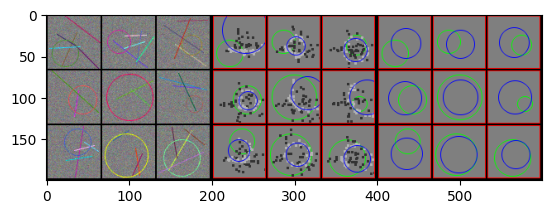

Storing snapshot. Validation loss: 19.73
Iteration:     51, DSAC Expected Loss: 17.45, DSAC Top Loss: 16.34, Direct Loss: 17.92, Time: 2.37s
Iteration:     52, DSAC Expected Loss: 15.32, DSAC Top Loss: 14.33, Direct Loss: 17.19, Time: 2.27s
Iteration:     53, DSAC Expected Loss: 18.17, DSAC Top Loss: 16.50, Direct Loss: 18.79, Time: 2.30s
Iteration:     54, DSAC Expected Loss: 15.02, DSAC Top Loss: 13.57, Direct Loss: 25.78, Time: 2.25s
Iteration:     55, DSAC Expected Loss: 17.40, DSAC Top Loss: 15.83, Direct Loss: 19.53, Time: 2.21s
Iteration:     56, DSAC Expected Loss: 15.53, DSAC Top Loss: 13.98, Direct Loss: 20.30, Time: 2.25s
Iteration:     57, DSAC Expected Loss: 18.61, DSAC Top Loss: 18.27, Direct Loss: 20.57, Time: 2.28s
Iteration:     58, DSAC Expected Loss: 15.41, DSAC Top Loss: 13.96, Direct Loss: 16.28, Time: 2.31s
Iteration:     59, DSAC Expected Loss: 16.01, DSAC Top Loss: 14.80, Direct Loss: 22.57, Time: 2.29s
Iteration:     60, DSAC Expected Loss: 17.48, DSAC Top Loss

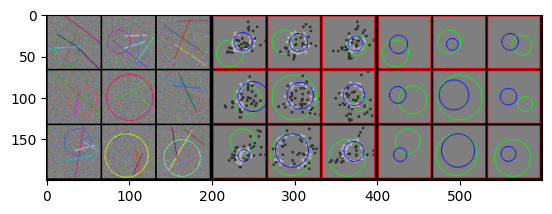

Storing snapshot. Validation loss: 16.65
Iteration:     61, DSAC Expected Loss: 16.95, DSAC Top Loss: 16.52, Direct Loss: 18.51, Time: 2.30s
Iteration:     62, DSAC Expected Loss: 14.30, DSAC Top Loss: 13.12, Direct Loss: 22.13, Time: 2.28s
Iteration:     63, DSAC Expected Loss: 18.02, DSAC Top Loss: 16.92, Direct Loss: 23.02, Time: 2.24s
Iteration:     64, DSAC Expected Loss: 16.17, DSAC Top Loss: 14.99, Direct Loss: 21.11, Time: 2.25s
Iteration:     65, DSAC Expected Loss: 15.81, DSAC Top Loss: 14.24, Direct Loss: 21.96, Time: 2.22s
Iteration:     66, DSAC Expected Loss: 16.64, DSAC Top Loss: 16.18, Direct Loss: 20.76, Time: 2.28s
Iteration:     67, DSAC Expected Loss: 15.13, DSAC Top Loss: 14.76, Direct Loss: 19.06, Time: 2.54s
Iteration:     68, DSAC Expected Loss: 14.52, DSAC Top Loss: 13.57, Direct Loss: 19.71, Time: 2.32s
Iteration:     69, DSAC Expected Loss: 17.27, DSAC Top Loss: 16.61, Direct Loss: 21.71, Time: 2.26s
Iteration:     70, DSAC Expected Loss: 14.84, DSAC Top Loss

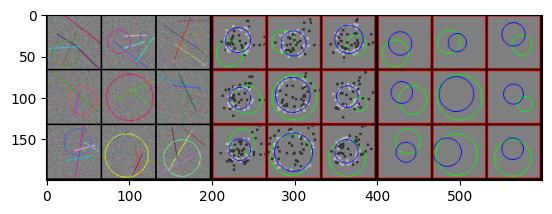

Storing snapshot. Validation loss: 13.88
Iteration:     71, DSAC Expected Loss: 15.12, DSAC Top Loss: 14.85, Direct Loss: 16.59, Time: 2.36s
Iteration:     72, DSAC Expected Loss: 13.74, DSAC Top Loss: 13.23, Direct Loss: 16.36, Time: 2.24s
Iteration:     73, DSAC Expected Loss: 14.87, DSAC Top Loss: 14.11, Direct Loss: 23.42, Time: 2.28s
Iteration:     74, DSAC Expected Loss: 14.17, DSAC Top Loss: 14.15, Direct Loss: 21.23, Time: 2.27s
Iteration:     75, DSAC Expected Loss: 12.38, DSAC Top Loss: 12.06, Direct Loss: 12.80, Time: 2.29s
Iteration:     76, DSAC Expected Loss: 12.28, DSAC Top Loss: 12.16, Direct Loss: 17.13, Time: 2.20s
Iteration:     77, DSAC Expected Loss: 16.56, DSAC Top Loss: 15.95, Direct Loss: 19.73, Time: 2.28s
Iteration:     78, DSAC Expected Loss: 14.50, DSAC Top Loss: 14.26, Direct Loss: 16.72, Time: 2.28s
Iteration:     79, DSAC Expected Loss: 12.94, DSAC Top Loss: 12.69, Direct Loss: 17.33, Time: 2.31s
Iteration:     80, DSAC Expected Loss: 12.51, DSAC Top Loss

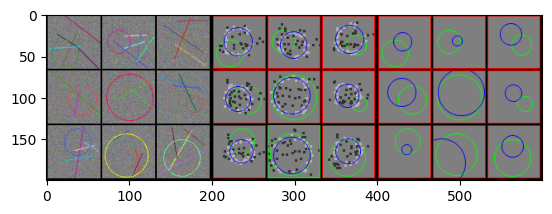

Storing snapshot. Validation loss: 13.67
Iteration:     81, DSAC Expected Loss: 12.53, DSAC Top Loss: 12.33, Direct Loss: 15.01, Time: 2.33s
Iteration:     82, DSAC Expected Loss: 14.66, DSAC Top Loss: 14.53, Direct Loss: 16.60, Time: 2.21s
Iteration:     83, DSAC Expected Loss: 13.68, DSAC Top Loss: 13.69, Direct Loss: 18.22, Time: 2.25s
Iteration:     84, DSAC Expected Loss: 11.65, DSAC Top Loss: 11.16, Direct Loss: 16.88, Time: 2.24s
Iteration:     85, DSAC Expected Loss: 13.40, DSAC Top Loss: 12.88, Direct Loss: 16.51, Time: 2.23s
Iteration:     86, DSAC Expected Loss: 13.99, DSAC Top Loss: 13.77, Direct Loss: 16.49, Time: 2.26s
Iteration:     87, DSAC Expected Loss: 12.10, DSAC Top Loss: 11.45, Direct Loss: 15.12, Time: 2.28s
Iteration:     88, DSAC Expected Loss: 11.62, DSAC Top Loss: 10.77, Direct Loss: 15.67, Time: 2.21s
Iteration:     89, DSAC Expected Loss: 14.95, DSAC Top Loss: 13.90, Direct Loss: 19.76, Time: 2.26s
Iteration:     90, DSAC Expected Loss: 13.39, DSAC Top Loss

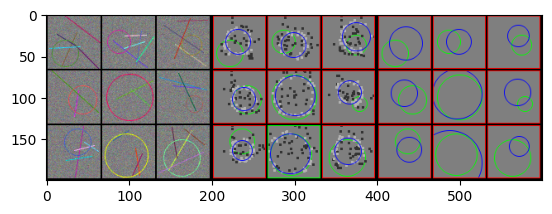

Storing snapshot. Validation loss: 12.38
Iteration:     91, DSAC Expected Loss: 11.92, DSAC Top Loss: 11.36, Direct Loss: 14.54, Time: 2.28s
Iteration:     92, DSAC Expected Loss: 14.93, DSAC Top Loss: 14.08, Direct Loss: 16.11, Time: 2.30s
Iteration:     93, DSAC Expected Loss: 12.92, DSAC Top Loss: 12.34, Direct Loss: 16.85, Time: 2.26s
Iteration:     94, DSAC Expected Loss: 14.20, DSAC Top Loss: 13.49, Direct Loss: 17.76, Time: 2.25s
Iteration:     95, DSAC Expected Loss: 13.48, DSAC Top Loss: 12.71, Direct Loss: 17.07, Time: 2.27s
Iteration:     96, DSAC Expected Loss: 15.44, DSAC Top Loss: 15.05, Direct Loss: 17.82, Time: 2.27s
Iteration:     97, DSAC Expected Loss: 12.21, DSAC Top Loss: 11.41, Direct Loss: 18.98, Time: 2.25s
Iteration:     98, DSAC Expected Loss: 13.53, DSAC Top Loss: 12.20, Direct Loss: 17.16, Time: 2.22s
Iteration:     99, DSAC Expected Loss: 13.61, DSAC Top Loss: 12.65, Direct Loss: 15.13, Time: 2.26s
Iteration:    100, DSAC Expected Loss: 13.65, DSAC Top Loss

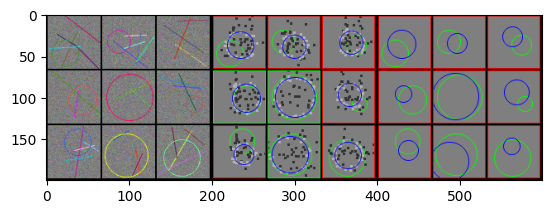

Storing snapshot. Validation loss: 11.05
Done without errors.


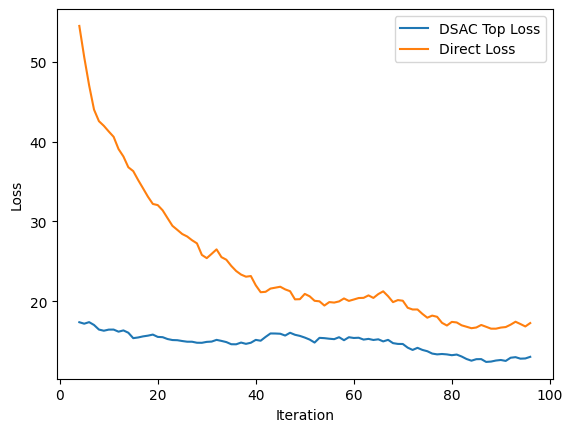

In [13]:
# train and plot losses
train_circle_dsac(params, dataset, loss, dsac)
plot_loss('./models/log_dsac_circle.txt')

## Bonus Task
(incredible fame)

DSAC and direct prediction perform similarly well in this setup. Try to adapt the synthetic image generation to cater to the advantages of either method, i.e. make the task easier or more difficult in certain ways.